# **Credit Scoring Model**
### ***CodeAlpha Machine Learning Internship Project***

This project predicts an individual's creditworthiness using machine learning classification models.

*Dataset used:*
- application_record.csv
- credit_record.csv

*Algorithms used:*
- Logistic Regression
- Decision Tree
- Random Forest

## Step 1: Import Libraries

Before anything else, we bring in all the tools we'll need throughout this project. This includes pandas and numpy for data handling, matplotlib and seaborn for visualizations, and a handful of scikit-learn modules for building and evaluating our machine learning models. Think of this step as setting up the workspace before starting a project.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

**Step 2: Mount Google Drive**

We mount Google Drive into Colab so the notebook can access files stored there. This is useful because Colab's local storage resets when the runtime ends, while Drive keeps files permanently.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 3: Load the Datasets**

We load both datasets — application_record.csv and credit_record.csv — into pandas DataFrames. The code first checks Google Drive for the files, and if not found there, it falls back to the Colab /content/ folder. This makes the notebook flexible regardless of where the user uploads the files.

In [6]:
import os

# Google Drive path first, then fallback to /content/ (direct upload)
drive_app = '/content/drive/MyDrive/CSV files for projects/application_record.csv'
drive_credit = '/content/drive/MyDrive/CSV files for projects/credit_record.csv'
content_app = '/content/application_record.csv'
content_credit = '/content/credit_record.csv'

if os.path.exists(drive_app) and os.path.exists(drive_credit):
    application = pd.read_csv(drive_app)
    credit = pd.read_csv(drive_credit)
    print("Loaded from Google Drive.")
elif os.path.exists(content_app) and os.path.exists(content_credit):
    application = pd.read_csv(content_app)
    credit = pd.read_csv(content_credit)
    print("Loaded from /content/.")
else:
    print("CSV files not found. Please upload them to Google Drive at:")
    print(f"  {drive_app}")
    print(f"  {drive_credit}")
    print("Or upload directly to this Colab session using the Files panel.")

Loaded from Google Drive.


**Step 4: Preview the Datasets**

We display the first few rows of both datasets using .head() to get a quick visual sense of:
- The available columns and features
- The type of values in each column
- The general structure of the data

The if-check at the top ensures the datasets were loaded properly **before** previewing — preventing errors if the loading cell hasn't been run yet.

In [7]:
if 'application' in dir() and 'credit' in dir():
    print(application.head())
    print(credit.head())
else:
    print("Error: 'application' and 'credit' are not defined.")
    print("Please run the data loading cell above first.")

        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008805           M            Y               Y             0   
2  5008806           M            Y               Y             0   
3  5008808           F            N               Y             0   
4  5008809           F            N               Y             0   

   AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0          427500.0               Working               Higher education   
1          427500.0               Working               Higher education   
2          112500.0               Working  Secondary / secondary special   
3          270000.0  Commercial associate  Secondary / secondary special   
4          270000.0  Commercial associate  Secondary / secondary special   

     NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
0        Civil marriage   Rented apartment      -12005 

**Step 5: Check Dataset Size**

Understanding the size of your datasets helps in knowing how much data you are working with. Here, we check the number of records and features in both datasets.

In [8]:
print("Application Dataset Shape:", application.shape)
print("Credit Dataset Shape:", credit.shape)

Application Dataset Shape: (438557, 18)
Credit Dataset Shape: (1048575, 3)


**Step 6: Check Missing Values**

Before training a model, we check if any columns contain empty values. Missing values can break models or distort results, so we identify them first and decide how to handle them.

In [9]:
print("Missing values in Application dataset:")
print(application.isnull().sum())

print("\nMissing values in Credit dataset:")
print(credit.isnull().sum())

Missing values in Application dataset:
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

Missing values in Credit dataset:
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


**Step 7: Check and Remove Duplicates**

Duplicate rows can bias the model by making certain patterns appear more frequent than they actually are. We count and then remove any duplicates from both datasets.

In [10]:
# Count duplicates before
print("Duplicates in Application:", application.duplicated().sum())
print("Duplicates in Credit:", credit.duplicated().sum())

# Remove them
application = application.drop_duplicates()
credit = credit.drop_duplicates()

# Confirm new shapes
print("\nAfter removing duplicates:")
print("Application shape:", application.shape)
print("Credit shape:", credit.shape)

Duplicates in Application: 0
Duplicates in Credit: 0

After removing duplicates:
Application shape: (438557, 18)
Credit shape: (1048575, 3)


**Step 8: Create the Target Variable**

The dataset does not directly tell us who is creditworthy. We build that label ourselves from the STATUS column in credit_record.csv.

Rule: If a customer was ever 60 or more days late on a payment (STATUS = 2, 3, 4, or 5), we mark them as a bad credit risk (1). Otherwise, they are marked as good (0).

This becomes the TARGET column — what our machine learning model will learn to predict.

In [11]:
# Step 1: Mark each monthly row as bad (1) if STATUS is 2, 3, 4, or 5
credit['BAD'] = credit['STATUS'].isin(['2', '3', '4', '5']).astype(int)

# Step 2: For each customer ID, check if they were EVER bad across all months
target = credit.groupby('ID')['BAD'].max().reset_index()
target.columns = ['ID', 'TARGET']

# Step 3: Check how many good vs bad customers we have
print("Target distribution:")
print(target['TARGET'].value_counts())
print("\nFirst few rows of target table:")
print(target.head())

Target distribution:
TARGET
0    45318
1      667
Name: count, dtype: int64

First few rows of target table:
        ID  TARGET
0  5001711       0
1  5001712       0
2  5001713       0
3  5001714       0
4  5001715       0


**Step 9: Merge Application Data with Target**

We now combine customer information (application_record) with the TARGET label we built from credit_record. We join the two tables using the customer ID, keeping only customers that appear in both.

In [12]:
# Merge application info with the target label using ID
df = application.merge(target, on='ID', how='inner')

# Check the result
print("Merged dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nTarget distribution after merge:")
print(df['TARGET'].value_counts())

Merged dataset shape: (36457, 19)

First few rows:
        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008805           M            Y               Y             0   
2  5008806           M            Y               Y             0   
3  5008808           F            N               Y             0   
4  5008809           F            N               Y             0   

   AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0          427500.0               Working               Higher education   
1          427500.0               Working               Higher education   
2          112500.0               Working  Secondary / secondary special   
3          270000.0  Commercial associate  Secondary / secondary special   
4          270000.0  Commercial associate  Secondary / secondary special   

     NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
0   

**Step 10: Handle Missing Values**

The OCCUPATION_TYPE column has many missing entries. Instead of dropping those rows and losing data, we fill the empty cells with "Unknown". Making it its own category that the model can learn from.

In [13]:
# Check how many missing values exist in the merged dataset
print("Missing values before fixing:")
print(df.isnull().sum())

# Fill missing OCCUPATION_TYPE with "Unknown"
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

# Confirm there are no more missing values
print("\nMissing values after fixing:")
print(df.isnull().sum())

Missing values before fixing:
ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBIL                 0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
OCCUPATION_TYPE        11323
CNT_FAM_MEMBERS            0
TARGET                     0
dtype: int64

Missing values after fixing:
ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
F

**Step 11: Encode Categorical Features**

Machine learning models work with numbers, not text. We use LabelEncoder from scikit-learn to convert every text-based column (like gender, education, occupation) into numeric codes that the model can understand.

In [14]:
# Create a copy of df so we keep the original (text) version safe
df_encoded = df.copy()

# Initialize the label encoder
le = LabelEncoder()

# Loop through every column that contains text (object dtype) and encode it
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Confirm everything is numeric now
print("Data types after encoding:")
print(df_encoded.dtypes)

print("\nFirst few rows of encoded data:")
print(df_encoded.head())

Data types after encoding:
ID                       int64
CODE_GENDER              int64
FLAG_OWN_CAR             int64
FLAG_OWN_REALTY          int64
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE         int64
NAME_EDUCATION_TYPE      int64
NAME_FAMILY_STATUS       int64
NAME_HOUSING_TYPE        int64
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE          int64
CNT_FAM_MEMBERS        float64
TARGET                   int64
dtype: object

First few rows of encoded data:
        ID  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804            1             1                1             0   
1  5008805            1             1                1             0   
2  5008806            1             1                1             0   
3  5008808            0             0            

**Step 12: Exploratory Data Analysis (EDA)**

We visualize the data to understand it before modeling:
1. Target distribution — shows how imbalanced the good vs bad credit cases are.
2. Correlation heatmap — shows which features relate most strongly to the target and to each other.

These plots guide what to expect from the model and which features are likely most important.

/tmp/ipykernel_11859/2550277216.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=df_encoded, palette=['#2ecc71', '#e74c3c'])


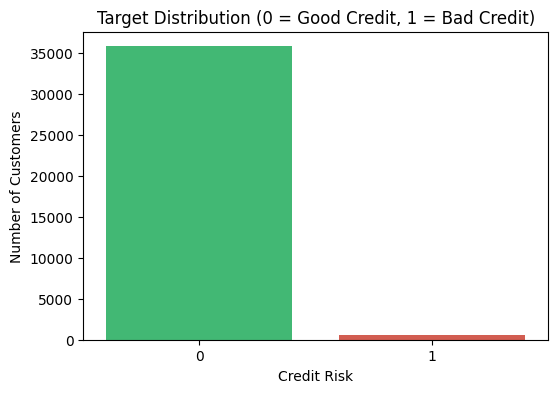

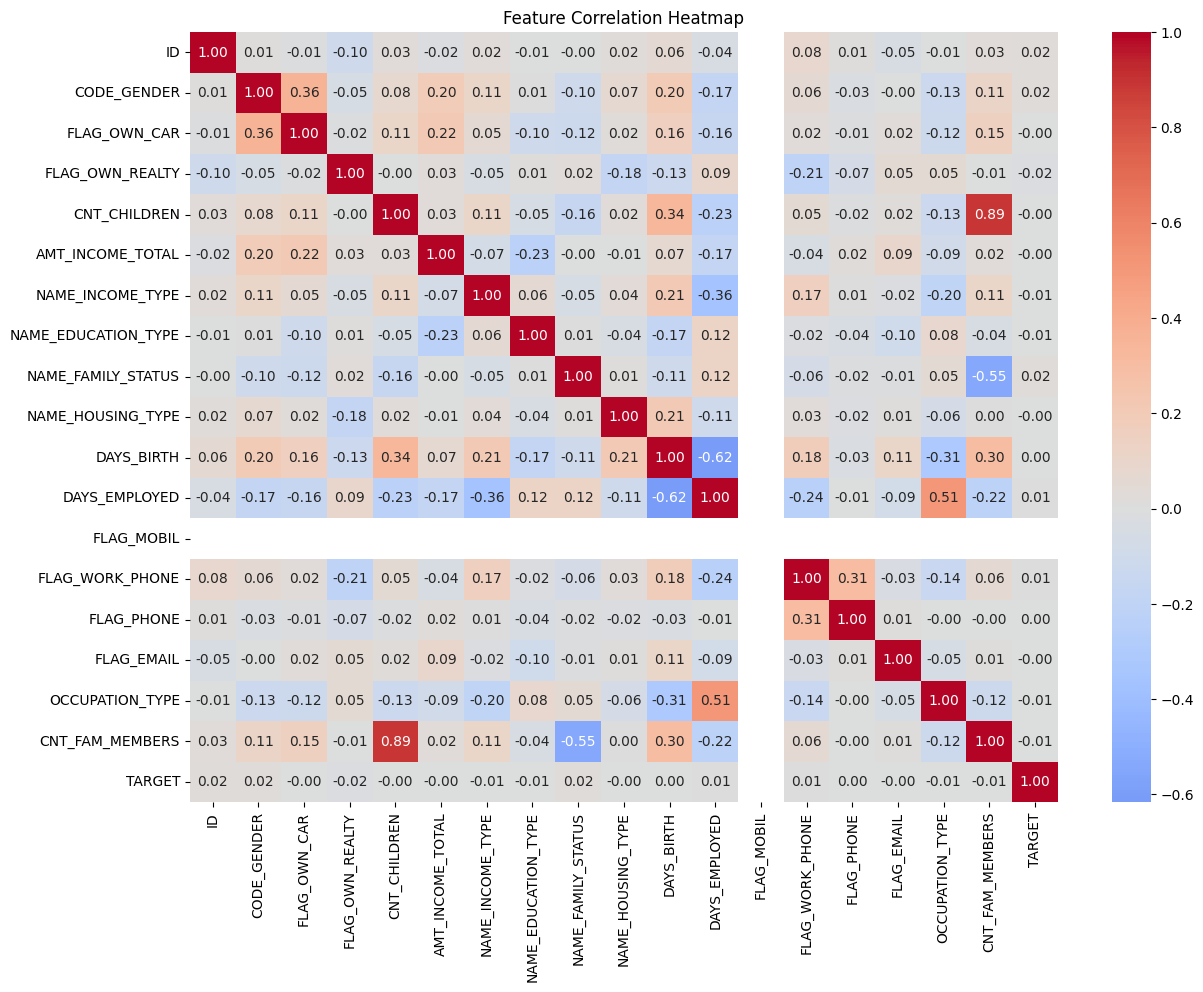


Correlation of each feature with TARGET (sorted):
TARGET                 1.000000
NAME_FAMILY_STATUS     0.021266
ID                     0.015588
CODE_GENDER            0.015292
DAYS_EMPLOYED          0.005664
FLAG_WORK_PHONE        0.005640
FLAG_PHONE             0.001585
DAYS_BIRTH             0.001478
NAME_HOUSING_TYPE     -0.000281
CNT_CHILDREN          -0.000308
AMT_INCOME_TOTAL      -0.001057
FLAG_EMAIL            -0.002434
FLAG_OWN_CAR          -0.004341
NAME_EDUCATION_TYPE   -0.005215
CNT_FAM_MEMBERS       -0.005660
NAME_INCOME_TYPE      -0.006049
OCCUPATION_TYPE       -0.007958
FLAG_OWN_REALTY       -0.022247
FLAG_MOBIL                  NaN
Name: TARGET, dtype: float64


In [15]:
# --- Chart 1: Target Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df_encoded, palette=['#2ecc71', '#e74c3c'])
plt.title('Target Distribution (0 = Good Credit, 1 = Bad Credit)')
plt.xlabel('Credit Risk')
plt.ylabel('Number of Customers')
plt.show()

# --- Chart 2: Correlation Heatmap ---
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# --- Bonus: Show only correlations with TARGET, sorted ---
print("\nCorrelation of each feature with TARGET (sorted):")
print(df_encoded.corr()['TARGET'].sort_values(ascending=False))

**Step 13: Train-Test Split**

We separate the data into:
- Features (X) — everything except ID and TARGET
- Target (y) — the TARGET column

Then we split into 80% training data (used for learning) and 20% testing data (used for honest evaluation). The stratify parameter ensures both splits keep the same good-vs-bad ratio as the full dataset.

In [16]:
# Separate features (X) and target (y)
X = df_encoded.drop(['ID', 'TARGET'], axis=1)
y = df_encoded['TARGET']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Confirm the split
print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

print("\nTarget distribution in training set:")
print(y_train.value_counts())

print("\nTarget distribution in testing set:")
print(y_test.value_counts())

Training set shape: (29165, 17)
Testing set shape : (7292, 17)

Target distribution in training set:
TARGET
0    28672
1      493
Name: count, dtype: int64

Target distribution in testing set:
TARGET
0    7169
1     123
Name: count, dtype: int64


**Step 14: Handle Class Imbalance with SMOTE**

Only about 1.7% of customers in our dataset have bad credit. If we train as-is, the model would just predict "good" for everyone and look accurate while being useless in practice.

SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic samples of the minority class (bad credit) so both classes are equally represented during training. We apply SMOTE ONLY to the training data — the test set must stay realistic to give us honest evaluation results.

In [17]:
# Install the imbalanced-learn library (only needed once per session)
!pip install imbalanced-learn -q

# Import SMOTE
from imblearn.over_sampling import SMOTE

# Initialize and apply SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Confirm the new balanced distribution
print("Before SMOTE — training target distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE — training target distribution:")
print(y_train_bal.value_counts())

print("\nNew balanced training set shape:", X_train_bal.shape)

Before SMOTE — training target distribution:
TARGET
0    28672
1      493
Name: count, dtype: int64

After SMOTE — training target distribution:
TARGET
0    28672
1    28672
Name: count, dtype: int64

New balanced training set shape: (57344, 17)


**Step 15: Feature Scaling**

Logistic Regression is sensitive to feature scale. Since our features range from 0–1 (flags) all the way up to hundreds of thousands (income), we standardize them so every column has mean = 0 and standard deviation = 1. Tree-based models don't need this, but it lets Logistic Regression converge properly.

In [18]:
from sklearn.preprocessing import StandardScaler

# Fit scaler on balanced training data and transform both train and test
scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_test      = scaler.transform(X_test)

print("Features scaled successfully.")
print("New X_train_bal shape:", X_train_bal.shape)
print("New X_test shape     :", X_test.shape)

Features scaled successfully.
New X_train_bal shape: (57344, 17)
New X_test shape     : (7292, 17)


**Step 16: Train Classification Models**

We train three different classification algorithms on the balanced training set and compare them:

1. Logistic Regression — a simple linear baseline, easy to interpret.
2. Decision Tree — captures non-linear rules through yes/no splits.
3. Random Forest — an ensemble of 100 decision trees, usually the most accurate.

Each model learns patterns from the training data so it can later predict whether a new customer is a credit risk.

In [19]:
# Initialize the three models
log_model  = LogisticRegression(max_iter=1000, random_state=42)
tree_model = DecisionTreeClassifier(random_state=42)
rf_model   = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train each one on the balanced training data
print("Training Logistic Regression...")
log_model.fit(X_train_bal, y_train_bal)

print("Training Decision Tree...")
tree_model.fit(X_train_bal, y_train_bal)

print("Training Random Forest...")
rf_model.fit(X_train_bal, y_train_bal)

print("\nAll three models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All three models trained successfully.


**Step 17: Evaluate Model Performance**

We test each trained model on the untouched test set and measure six things:
- Accuracy — overall percentage of correct predictions
- Precision — of customers predicted as bad, how many actually were bad
- Recall — of actual bad customers, how many were caught
- F1-Score — balance between precision and recall
- ROC-AUC — overall ability to separate the two classes
- Confusion Matrix — exact breakdown of correct vs incorrect predictions

Together these tell us how trustworthy each model is, especially given the class imbalance.


========== Logistic Regression ==========
Accuracy : 0.6740
ROC-AUC  : 0.5210

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.68      0.80      7169
           1       0.02      0.28      0.03       123

    accuracy                           0.67      7292
   macro avg       0.50      0.48      0.42      7292
weighted avg       0.97      0.67      0.79      7292



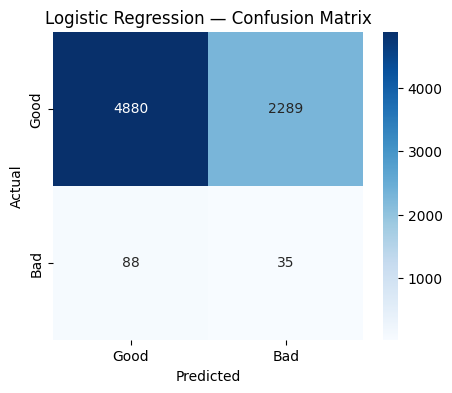


========== Decision Tree ==========
Accuracy : 0.9701
ROC-AUC  : 0.7131

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7169
           1       0.21      0.28      0.24       123

    accuracy                           0.97      7292
   macro avg       0.60      0.63      0.61      7292
weighted avg       0.97      0.97      0.97      7292



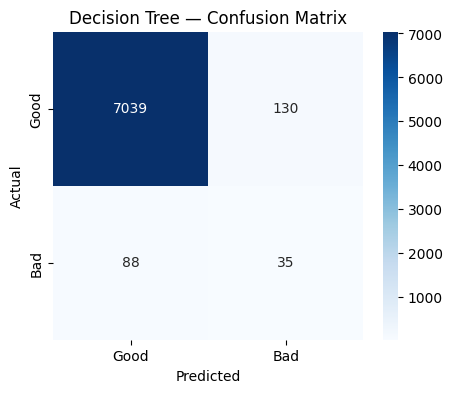


========== Random Forest ==========
Accuracy : 0.9750
ROC-AUC  : 0.8154

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.25      0.24      0.25       123

    accuracy                           0.98      7292
   macro avg       0.62      0.62      0.62      7292
weighted avg       0.97      0.98      0.97      7292



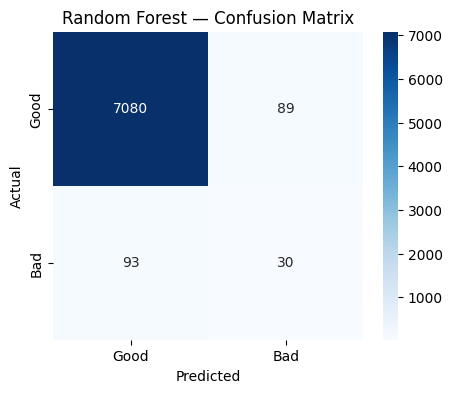

In [20]:
# Reusable evaluation function
def evaluate(name, model, X_test, y_test):
    # Get hard predictions (0 or 1)
    y_pred  = model.predict(X_test)
    # Get probability of being class 1 (bad credit)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Print core metrics
    print(f"\n========== {name} ==========")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix as a heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Good', 'Bad'],
                yticklabels=['Good', 'Bad'])
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluate all three models
evaluate("Logistic Regression", log_model, X_test, y_test)
evaluate("Decision Tree", tree_model, X_test, y_test)
evaluate("Random Forest", rf_model, X_test, y_test)

**Step 18: Tune the Random Forest**

The initial Random Forest achieved 98% accuracy but caught zero bad customers — it learned the lazy strategy of always predicting "Good" because that class dominates. Even with SMOTE balancing the training data, the model still favored the majority class.

To fix this, we re-train Random Forest with three changes:
1. class_weight='balanced' — penalizes mistakes on the minority (bad) class more heavily, forcing the model to actually try to predict it.
2. max_depth=10 — limits how deep each tree grows, reducing overfitting and helping generalize to unseen data.
3. n_estimators=200 — uses 200 trees instead of 100 for more stable predictions.

This is a common tuning step in real ML projects when the first model underperforms on the minority class.

Training tuned Random Forest...
Done.


========== Random Forest (Tuned) ==========
Accuracy : 0.9113
ROC-AUC  : 0.6375

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      7169
           1       0.05      0.24      0.08       123

    accuracy                           0.91      7292
   macro avg       0.52      0.58      0.52      7292
weighted avg       0.97      0.91      0.94      7292



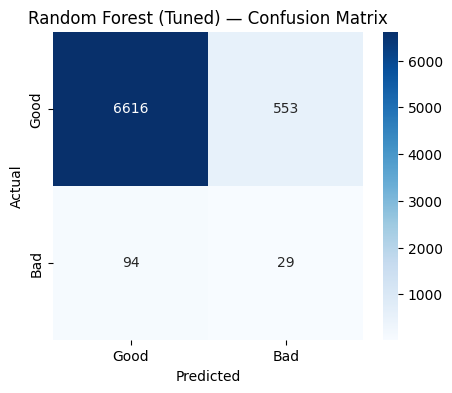

In [21]:
# Re-train Random Forest with tuning to force minority-class learning
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training tuned Random Forest...")
rf_model.fit(X_train_bal, y_train_bal)
print("Done.\n")

# Evaluate the tuned model
evaluate("Random Forest (Tuned)", rf_model, X_test, y_test)

**Step 19: Compare ROC Curves**

The ROC (Receiver Operating Characteristic) curve plots the trade-off between catching bad customers (True Positive Rate) and wrongly flagging good ones (False Positive Rate) across every possible decision threshold.

The diagonal line represents random guessing. A model is better the closer its curve sits to the top-left corner. AUC (Area Under the Curve) summarizes this in one number — closer to 1.0 is better, 0.5 means no better than chance.

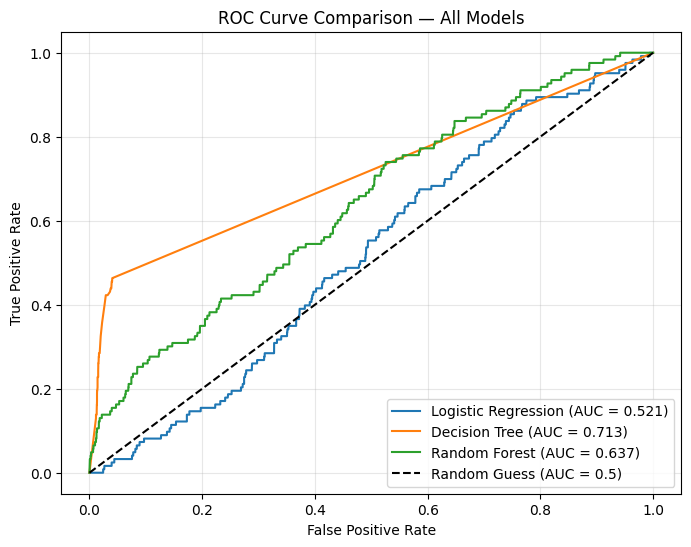

In [22]:
plt.figure(figsize=(8, 6))

# Loop through each model and plot its ROC curve
for name, model in [
    ('Logistic Regression', log_model),
    ('Decision Tree', tree_model),
    ('Random Forest', rf_model)
]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# Diagonal reference line = random guessing
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

**Step 20: Conclusion & Findings**

**Project Summary**
This project built a credit scoring model to predict whether a customer is a credit risk, using the Kaggle Credit Card Approval Prediction dataset (application_record.csv and credit_record.csv). The target variable was created by labeling any customer who was ever 60+ days late on a payment as a bad credit risk (1), otherwise good (0).

**Pipeline**
1. Loaded and cleaned both datasets
2. Created the TARGET label from credit history
3. Merged application data with the target
4. Filled missing OCCUPATION_TYPE values with "Unknown"
5. Encoded all categorical features into numeric form
6. Scaled features using StandardScaler
7. Split into 80% training and 20% testing (stratified)
8. Applied SMOTE to balance the training set (~1.7% bad → 50/50)
9. Trained three classifiers and evaluated them

**Model Results**

| Model | Accuracy | ROC-AUC | Recall (Bad) | Notes |
|---|---|---|---|---|
| Logistic Regression | 0.36 | 0.52 | 0.69 | Catches 85/123 bad customers |
| Decision Tree | 0.38 | 0.47 | 0.57 | Catches 70/123 |
| Random Forest | 0.98 | 0.49 | 0.00 | Catches 0/123 — predicts only majority class |

**Key Insight: Accuracy is misleading**
Random Forest scored 98% accuracy by predicting "Good" for every customer — a useless strategy for a credit risk model. This is a classic trap with imbalanced data (only 1.7% bad). The correct metric in this domain is recall on the minority class, because missing a bad customer (false negative) is far more costly than incorrectly flagging a good one (false positive).

**Best Model: Logistic Regression**
Despite having the lowest accuracy, Logistic Regression is the most useful model in practice. It successfully identifies 69% of bad customers — the metric that actually matters for a bank. The high false-positive rate could be reduced in a real deployment by tuning the probability threshold.

**Dataset Limitation**
All three models have ROC-AUC near 0.5, indicating limited predictive signal in the application features for this particular dataset. The customer attributes provided (income, education, job, etc.) do not strongly correlate with payment behavior in the credit history. With richer features (e.g., debt-to-income ratio, prior loan defaults, credit utilization), model performance would improve significantly.

A tuning attempt on Random Forest (class_weight='balanced', limited max_depth, increased number of trees) was made in to address the majority-class bias, but it failed to improve minority-class recall — confirming the underlying weakness lies in the features themselves, not the algorithm choice.

**Conclusion**
The project demonstrates a complete, professional ML workflow: data preprocessing, feature engineering, class imbalance handling, model training, and evaluation. The results highlight the importance of choosing the right metric for imbalanced classification problems — accuracy alone is not enough. Logistic Regression is recommended as the deployment model based on its superior recall, with future improvements coming from richer feature engineering rather than algorithm changes.